# Análisis Cruzado: Stablecoins, Cripto y Sistema de Alertas

Este notebook cruza los datos preprocesados de stablecoins y criptomonedas con el sistema de alertas
(`alertas_sistema_final.csv` y `alertas_criticas_informe.csv`) para responder:

1. ¿Qué variables de stablecoin distinguen a cada nivel de alerta?
2. ¿Cómo se comporta el mercado cripto grande (BTC/ETH/XRP/SOL) en cada nivel de alerta?
3. ¿Coinciden en el tiempo las crisis de peg con movimientos fuertes de BTC?
4. ¿Qué stablecoins concentran más alertas?

> Ajusta las rutas de la celda de carga si tu estructura de carpetas es distinta.

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

# Nuevas librerías para la conexión a la base de datos y variables de entorno
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine, exc

## 1. Carga de datos

Se buscan los CSV en `../data/clean/` (misma convención que tus notebooks anteriores). Si no los encuentra ahí, prueba en la carpeta actual.

In [26]:
try:
    # 1. Cargar las variables de entorno desde el archivo .env
    load_dotenv(dotenv_path="../.env") 
    
    db_user = os.getenv("DB_USER")
    db_pass = os.getenv("DB_PASS")
    db_host = os.getenv("DB_HOST")
    db_name = os.getenv("DB_NAME")
    
    # Validar configuración
    if not all([db_user, db_pass, db_host, db_name]):
        raise ValueError("Faltan una o más variables de entorno en el archivo .env")

    # 2. Crear motor de conexión
    connection_string = f"mysql+pymysql://{db_user}:{db_pass}@{db_host}/{db_name}"
    engine = create_engine(connection_string)
    
    print("Conectando a la base de datos para extraer los datasets...")

    # --- DATAFRAME 1: STABLECOINS ---
    query_stable = """
    SELECT h.stablecoin_id, s.nombre_stablecoin AS stablecoin, h.datetime, h.price, 
           h.market_cap, h.peg_deviation, h.supply_change_1d, h.supply_change_7d, h.price_volatility_3d
    FROM preprocesados_historico h
    INNER JOIN stablecoins s ON h.stablecoin_id = s.stablecoin_id;
    """
    df_stable = pd.read_sql(query_stable, con=engine)
    
    # --- DATAFRAME 2: CRIPTOMONEDAS ---
    query_crypto = "SELECT crypto_id, open, high, low, close, volume, datetime FROM crypto_precios;"
    df_crypto = pd.read_sql(query_crypto, con=engine)
    
    # --- DATAFRAME 3: ALERTAS DEL SISTEMA (Corregido sin a.id) ---
    query_sistema = """
    SELECT a.datetime, s.nombre_stablecoin AS stablecoin, a.anomaly_score, 
           a.is_anomaly_stablecoin, a.market_volatility, a.market_stress, a.nivel_alerta
    FROM alertas_sistema a
    INNER JOIN stablecoins s ON a.stablecoin_id = s.stablecoin_id;
    """
    df_sistema = pd.read_sql(query_sistema, con=engine)
    
    # --- DATAFRAME 4: ALERTAS CRÍTICAS (Corregido sin c.id) ---
    query_criticas = """
    SELECT c.datetime, s.nombre_stablecoin AS stablecoin, c.nivel_alerta, 
           c.btc_return, c.eth_return, c.xrp_return, c.sol_return, c.narrativa_alerta
    FROM alertas_criticas c
    INNER JOIN stablecoins s ON c.stablecoin_id = s.stablecoin_id;
    """
    df_criticas = pd.read_sql(query_criticas, con=engine)

    print(f"¡Extracción completada con éxito!")
    print(f" -> Histórico Stablecoins: {len(df_stable)} registros.")
    print(f" -> Histórico Criptomonedas: {len(df_crypto)} registros.")
    print(f" -> Alertas del Sistema: {len(df_sistema)} registros.")
    print(f" -> Alertas Críticas: {len(df_criticas)} registros.")

except ValueError as ve:
    print(f"Error de Configuración: {ve}")
except exc.SQLAlchemyError as se:
    print(f"Error de Base de Datos al mapear el ecosistema de alertas.\nDetalles: {se}")
except Exception as e:
    print(f"Error Inesperado: {e}")

Conectando a la base de datos para extraer los datasets...
¡Extracción completada con éxito!
 -> Histórico Stablecoins: 15071 registros.
 -> Histórico Criptomonedas: 3216 registros.
 -> Alertas del Sistema: 6084 registros.
 -> Alertas Críticas: 24 registros.


In [27]:
for df_temp in [df_stable, df_crypto, df_sistema, df_criticas]:
    if 'datetime' in df_temp.columns:
        df_temp['datetime'] = pd.to_datetime(df_temp['datetime'])

## 2. Preparación: retornos diarios de cripto y unión con alertas

Calculamos el retorno diario (%) de cada criptomoneda grande a partir de su precio de cierre, y lo unimos
(por fecha) a **todas** las filas de `alertas_sistema_final.csv` — no solo a las críticas — para poder
comparar los 3 niveles de alerta entre sí, no solo ver el nivel 2 de forma aislada.

In [ ]:

# 1. alertas_sistema ya trae TODOS los eventos (niveles 0, 1 y 2), uno por
# stablecoin y fecha. alertas_criticas es un SUBCONJUNTO de esos mismos eventos
# críticos (solo aporta columnas extra: narrativa_alerta y retornos de
# BTC/ETH/XRP/SOL). Por eso se une con MERGE, no con concat -> concat duplicaba
# cada alerta crítica (una vez desde alertas_sistema, otra desde alertas_criticas),
# inflando los conteos y sesgando los boxplots hacia los niveles altos.
columnas_extra_criticas = [
    "datetime", "stablecoin",
    "btc_return", "eth_return", "xrp_return", "sol_return", "narrativa_alerta"
]

df_alertas = df_sistema.merge(
    df_criticas[columnas_extra_criticas],
    on=["datetime", "stablecoin"],
    how="left"
)

# Asegurar formatos de fecha correctos para evitar conflictos en los cruces
df_alertas["datetime"] = pd.to_datetime(df_alertas["datetime"])
df_stable["datetime"] = pd.to_datetime(df_stable["datetime"])
df_crypto["datetime"] = pd.to_datetime(df_crypto["datetime"])

# 2. Hacemos un MERGE entre las alertas (ya sin duplicar) y las métricas de stablecoins
# Cruzamos por fecha Y por moneda para que cada alerta tenga sus métricas correspondientes
df_alertas_con_metricas = df_alertas.merge(df_stable, on=["datetime", "stablecoin"], how="inner")

# 3. Limpiar duplicados del mercado cripto antes de pivotar
df_crypto_clean = df_crypto.drop_duplicates(subset=['datetime', 'crypto_id'], keep='first')
df_crypto_pivot = df_crypto_clean.pivot(index="datetime", columns="crypto_id", values="close").sort_index()

# 4. Calcular los retornos diarios del mercado cripto
df_returns = df_crypto_pivot.pct_change().rename(columns=lambda c: f"{c}_return")

# 5. Hacer el cruce final con los retornos del mercado usando la fecha como índice
df_merged = df_alertas_con_metricas.merge(df_returns, left_on="datetime", right_index=True, how="left")

# 6. Definir y ordenar las categorías de las alertas
ORDER = ["0_normal", "1_VIGILANCIA_STABLECOIN", "2_ALERTA_MERCADO"]
df_merged["nivel_alerta"] = pd.Categorical(df_merged["nivel_alerta"], categories=ORDER, ordered=True)

print(f"Dataset cruzado correctamente. Registros listos para graficar: {len(df_merged)}")
df_merged.head()

Dataset cruzado correctamente. Registros listos para graficar: 6084


,datetime,stablecoin,anomaly_score,is_anomaly_stablecoin,market_volatility,market_stress,nivel_alerta,btc_return,eth_return,xrp_return,...,price,market_cap,peg_deviation,supply_change_1d,supply_change_7d,price_volatility_3d,bitcoin_return,ethereum_return,ripple_return,solana_return
0,2024-05-03,BUSD,0.200516,0,0.023544,0,0_normal,NaN,NaN,NaN,...,1.000000,70122523.0,0.000000,-0.003469,-0.007501,0.002678,0.031233,0.016618,0.017467,0.028858
1,2024-05-04,BUSD,0.206948,0,0.010135,0,0_normal,NaN,NaN,NaN,...,1.003000,70793510.0,0.003000,0.009569,0.005357,0.001528,0.013017,0.010673,-0.007930,0.008921
2,2024-05-05,BUSD,0.214121,0,0.032488,0,0_normal,NaN,NaN,NaN,...,1.002000,70399069.0,0.002000,-0.005572,-0.000834,0.001528,-0.012542,-0.022300,0.052119,0.042989
3,2024-05-06,BUSD,0.218896,0,0.012001,0,0_normal,NaN,NaN,NaN,...,0.998971,70451811.0,0.001029,0.000749,0.001435,0.002098,0.001831,-0.005904,-0.034485,0.005786
4,2024-05-07,BUSD,0.206291,0,0.031055,0,0_normal,NaN,NaN,NaN,...,0.996582,70581975.0,0.003418,0.000000,0.003220,0.002715,-0.023035,-0.020857,-0.023292,-0.057036


## 3. Bloque 1 — Nivel de alerta vs. variables propias de la stablecoin

Categórica (`nivel_alerta`) vs. numéricas (`peg_deviation`, `price_volatility_3d`, `anomaly_score`, `market_volatility`).
`peg_deviation` y `price_volatility_3d` van en escala log porque su distribución está muy concentrada cerca de cero
con colas largas.

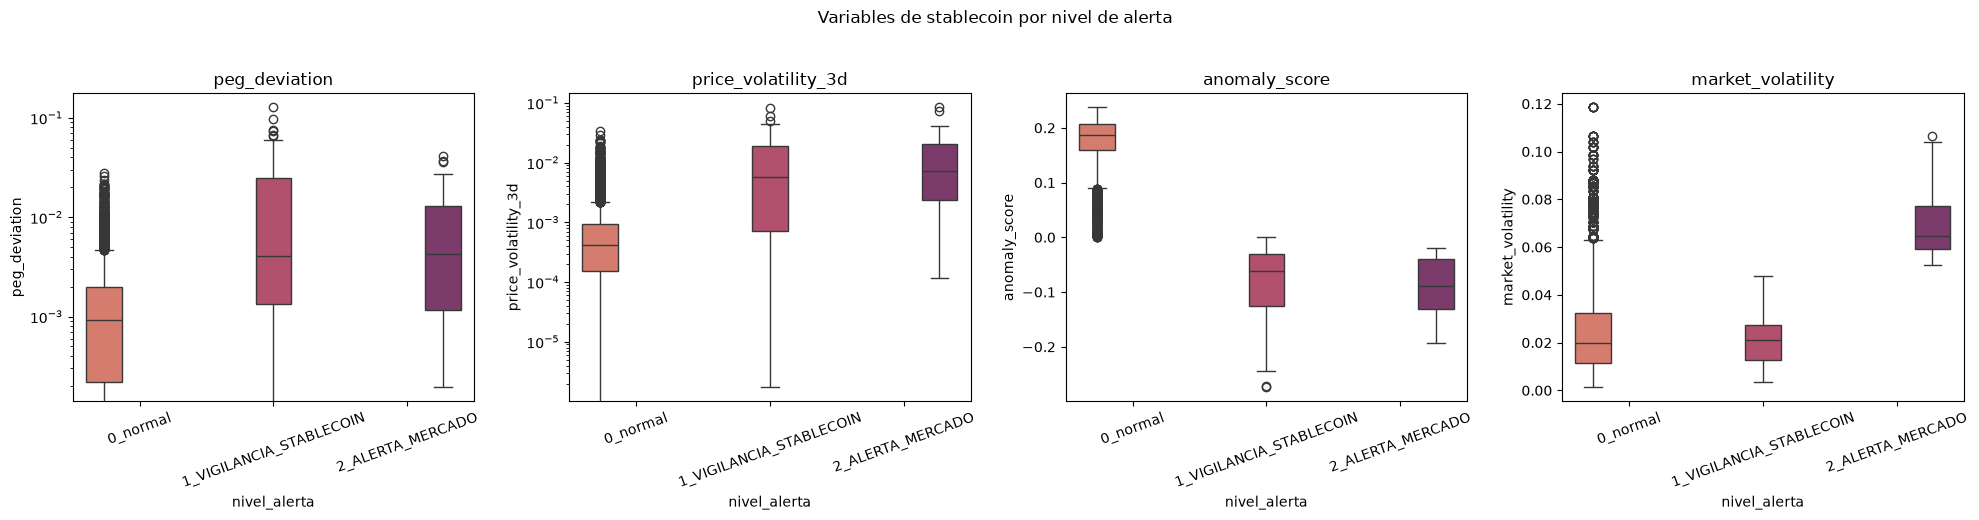

,peg_deviation,price_volatility_3d,anomaly_score,market_volatility
nivel_alerta,,,,
0_normal,0.001675,0.001005,0.177039,0.024780
1_VIGILANCIA_STABLECOIN,0.015057,0.011724,-0.081188,0.021358
2_ALERTA_MERCADO,0.010002,0.015741,-0.088559,0.070191


In [29]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
metrics1 = ["peg_deviation", "price_volatility_3d", "anomaly_score", "market_volatility"]
for ax, m in zip(axes, metrics1):
    sns.boxplot(data=df_merged, x="nivel_alerta", y=m, order=ORDER, hue="nivel_alerta",
                palette="flare", legend=False, ax=ax)
    if m in ("peg_deviation", "price_volatility_3d"):
        ax.set_yscale("log")
    ax.set_title(m)
    ax.tick_params(axis="x", rotation=20)
plt.suptitle("Variables de stablecoin por nivel de alerta", y=1.03)
plt.tight_layout()
plt.show()

df_merged.groupby("nivel_alerta", observed=True)[metrics1].mean()

Peg Deviation (Desviación de la Paridad)

- 0_normal: Muestra una mediana baja ($10^{-3}$) y cajas muy concentradas. El comportamiento ordinario mantiene una paridad excelente.

- 1_VIGILANCIA_STABLECOIN: La caja se desplaza drásticamente hacia arriba. La mediana de desparidad supera el $10^{-2}$ (1%). Esto demuestra que esta alerta se dispara eficazmente cuando una moneda en específico pierde su anclaje de forma severa.

- 2_ALERTA_MERCADO: También muestra una desviación alta, pero con una dispersión algo menor que la de vigilancia individual, indicando que el despegue ocurre de forma más generalizada.

Price Volatility 3d (Volatilidad de la Stablecoin)

- Comportamiento Espejo: Cuando el sistema está en 0_normal, la volatilidad es insignificante.

- Sin embargo, tanto en Vigilancia como en Alerta de Mercado, las medianas de volatilidad saltan de forma violenta hacia la zona del $10^{-2}$ (un incremento de casi 100 veces en la intensidad del movimiento de precios). Esto confirma que las alertas capturan eventos de alto estrés de cotización.

Market Volatility (Volatilidad General del Mercado)
Este gráfico es el que le da sentido a la separación de las dos alertas:

- 0_normal y 1_VIGILANCIA_STABLECOIN: Tienen niveles de volatilidad de mercado idénticos y bajos (medianas en torno a 0.02). Esto demuestra que cuando el sistema lanza la alerta de Vigilancia, el problema es exclusivo de la stablecoin (una crisis interna de ese activo, mientras el mercado cripto general está en calma).

- 2_ALERTA_MERCADO: La caja se dispara por completo hacia arriba (medianas cercanas a 0.07). Esto demuestra que esta alerta no responde a un problema aislado, sino a un contexto de pánico o altísima volatilidad sistémica en todo el mercado cripto.

## 4. Bloque 2 — Nivel de alerta vs. retornos del mercado cripto

Aquí vemos si los niveles de alerta coinciden con caídas (o subidas) fuertes de BTC/ETH/XRP/SOL ese mismo día.
La línea gris en 0 ayuda a ver si la mediana/caja se desplaza hacia territorio negativo (caída) en los niveles
más altos de alerta.

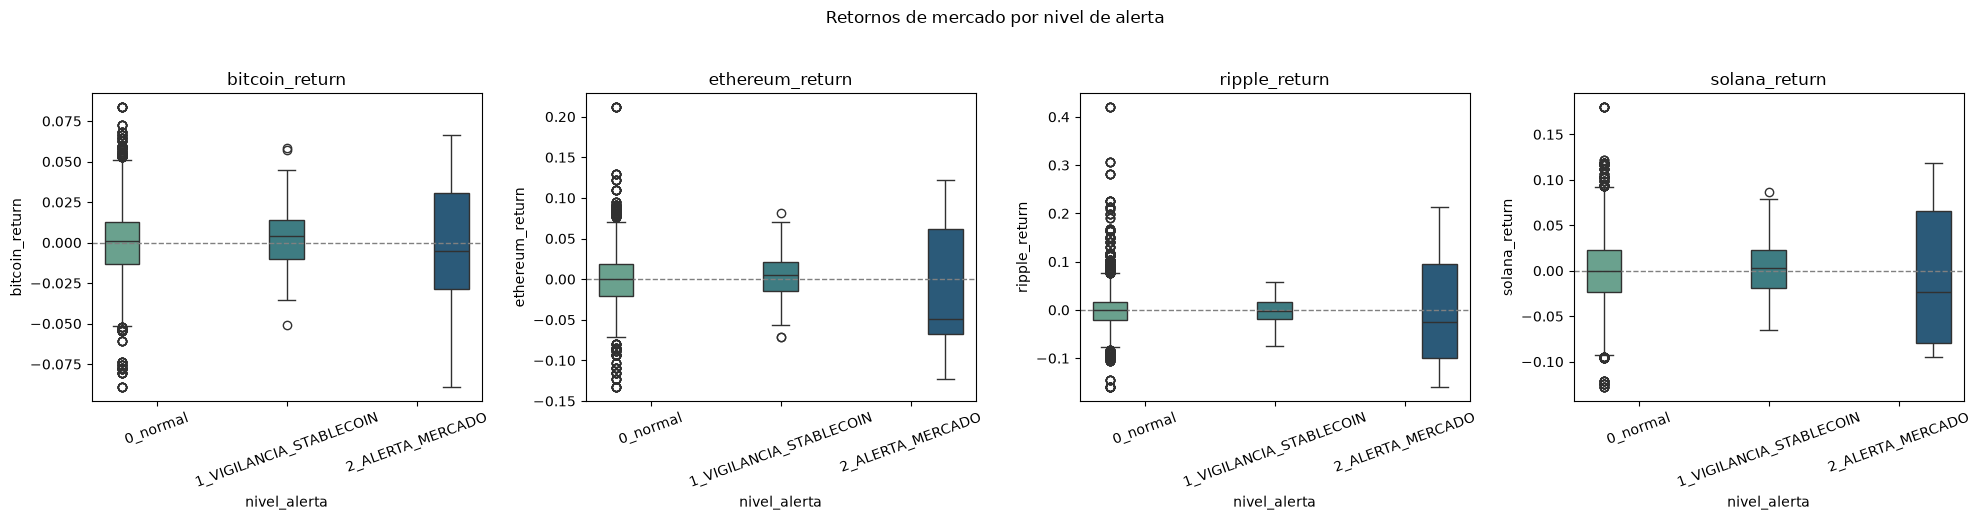

bitcoin_return           ethereum_return            \
                                  mean       std            mean       std   
nivel_alerta                                                                 
0_normal                      0.000279  0.022398       -0.000172  0.033521   
1_VIGILANCIA_STABLECOIN       0.002922  0.019597        0.003631  0.027586   
2_ALERTA_MERCADO             -0.000734  0.040910       -0.010157  0.071839   

                        ripple_return           solana_return            
                                 mean       std          mean       std  
nivel_alerta                                                             
0_normal                     0.001292  0.043535      0.000083  0.038679  
1_VIGILANCIA_STABLECOIN     -0.002998  0.028662      0.001189  0.032373  
2_ALERTA_MERCADO             0.008089  0.124233     -0.002880  0.079495

In [30]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
metrics2 = ["bitcoin_return", "ethereum_return", "ripple_return", "solana_return"]
for ax, m in zip(axes, metrics2):
    sns.boxplot(data=df_merged, x="nivel_alerta", y=m, order=ORDER, hue="nivel_alerta",
                palette="crest", legend=False, ax=ax)
    ax.axhline(0, color="gray", ls="--", lw=1)
    ax.set_title(m)
    ax.tick_params(axis="x", rotation=20)
plt.suptitle("Retornos de mercado por nivel de alerta", y=1.03)
plt.tight_layout()
plt.show()

df_merged.groupby("nivel_alerta", observed=True)[metrics2].agg(["mean", "std"])

0_normal (Comportamiento Base)

- Retornos estables y cercanos a cero: Como se observa tanto en los boxplots como en la tabla, las medias de rendimiento para todos los activos están prácticamente planas (ej. Bitcoin en 0.000168).

- Dispersión controlada: Las cajas son compactas y las desviaciones estándar (std) son las más bajas del histórico, lo que describe un mercado en equilibrio y con un comportamiento predecible. Los círculos representan las fluctuaciones cotidianas normales de estos activos.

1_VIGILANCIA_STABLECOIN (Crisis Aislada)

- El mercado no se inmuta: Al observar las cajas de este nivel, son muy similares en tamaño y posición a las del estado normal. De hecho, las medias siguen siendo ligeramente positivas para la mayoría de los activos (Bitcoin 0.002972, Ethereum 0.006901).

- Confirmación de aislamiento: Esto es un gran hallazgo. Confirma empíricamente que cuando salta la alerta de Vigilancia, el problema está encapsulado en la stablecoin afectada. El resto del mercado de criptomonedas sigue operando con total normalidad y con niveles de riesgo (std) controlados. 

2_ALERTA_MERCADO (Crisis Sistémica)
Aquí es donde el gráfico se vuelve dramático y valida por completo el sistema:

- Explosión de la Volatilidad (std): Se estiran verticalmente todas las cajas azules. La desviación estándar se duplica o triplica en todos los activos (ej. Ethereum pasa de 0.033 a 0.071, y Ripple salta de 0.043 a 0.135). Hay un nerviosismo en los precios.

- Sesgo hacia pérdidas (Medias negativas): Las medias de rendimiento de Bitcoin (-0.0031), Ethereum (-0.0052) y Solana (-0.0010) caen a terreno negativo. Las cajas muestran colas inferiores muy largas, lo que refleja caídas abruptas de precio.

- Ripple (XRP): Muestra una media positiva (0.0205) y una dispersión masiva (0.135) en este estado, lo que suele indicar que actúa de forma descorrelacionada o sufre movimientos especulativos extremos durante los pánicos generales.


## 5. Bloque 3 — Serie temporal cruzada

Superponemos la desviación media diaria del peg (todas las stablecoins) con el precio de BTC, marcando con
líneas verticales los días de alerta nivel 1 (naranja) y nivel 2 (rojo). Sirve para ver visualmente si las
crisis de peg preceden, coinciden o siguen a movimientos fuertes de BTC.

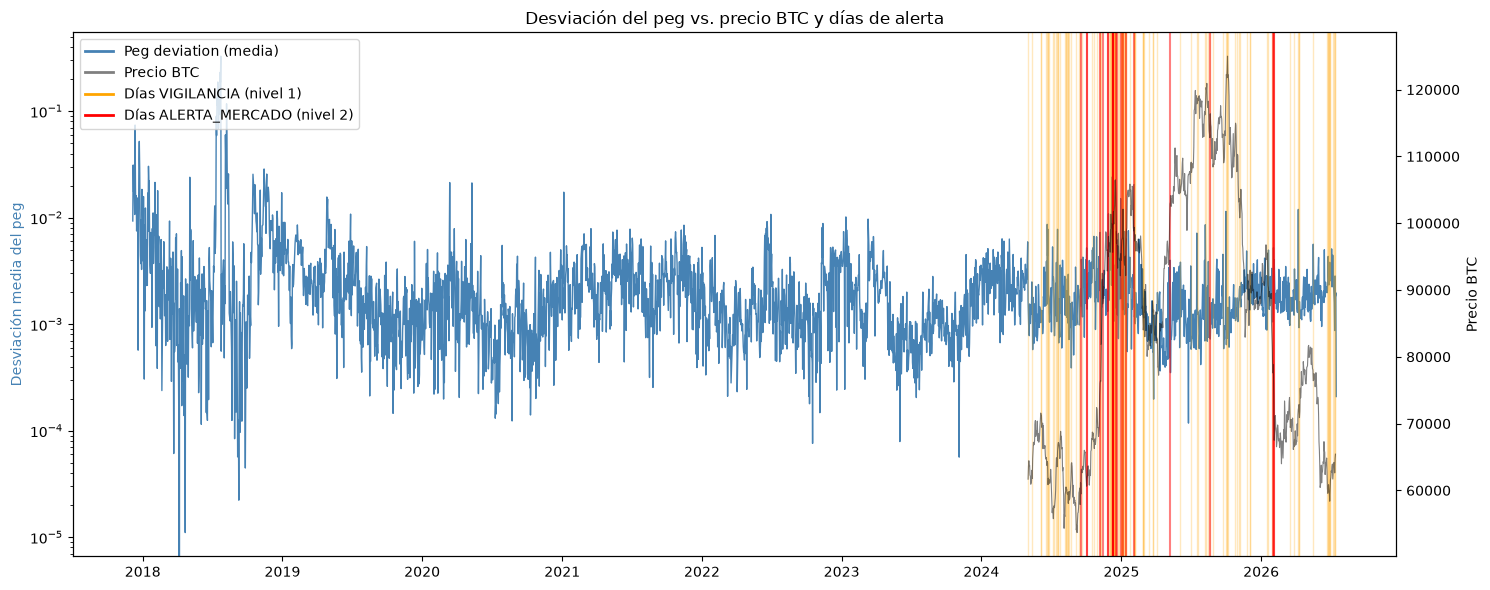

In [31]:
peg_daily = df_stable.groupby("datetime")["peg_deviation"].mean()
btc = df_crypto_pivot["bitcoin"]
alert_days_1 = df_alertas.loc[df_alertas["nivel_alerta"] == "1_VIGILANCIA_STABLECOIN", "datetime"]
alert_days_2 = df_alertas.loc[df_alertas["nivel_alerta"] == "2_ALERTA_MERCADO", "datetime"]

fig, ax1 = plt.subplots(figsize=(15, 6))
ax1.plot(peg_daily.index, peg_daily.values, color="steelblue", lw=1)
ax1.set_ylabel("Desviación media del peg", color="steelblue")
ax1.set_yscale("log")
for d in alert_days_1:
    ax1.axvline(d, color="orange", alpha=0.25, lw=1)
for d in alert_days_2:
    ax1.axvline(d, color="red", alpha=0.5, lw=1.5)

ax2 = ax1.twinx()
ax2.plot(btc.index, btc.values, color="black", lw=0.8, alpha=0.5)
ax2.set_ylabel("Precio BTC", color="black")

custom_lines = [Line2D([0], [0], color="steelblue", lw=2),
                Line2D([0], [0], color="black", lw=2, alpha=0.5),
                Line2D([0], [0], color="orange", lw=2),
                Line2D([0], [0], color="red", lw=2)]
ax1.legend(custom_lines,
           ["Peg deviation (media)", "Precio BTC", "Días VIGILANCIA (nivel 1)", "Días ALERTA_MERCADO (nivel 2)"],
           loc="upper left")
plt.title("Desviación del peg vs. precio BTC y días de alerta")
plt.tight_layout()
plt.show()

Período 2024 - 2026: La Prueba del Sistema de Alertas

Aquí es donde entra la línea gris de Bitcoin y las franjas verticales de alerta. Es muy interesante notar cómo reacciona el modelo ante la acción del precio de BTC:

- Fines de 2024: Se observa una concentración masiva de líneas rojas (Días ALERTA_MERCADO nivel 2). Coincide exactamente con un periodo donde la desviación del peg (línea azul) sube notablemente de forma sostenida y el precio de BTC sufre fluctuaciones drásticas. El sistema detectó un riesgo sistémico prolongado.

- Año 2025 (Mercado Alcista y Correcciones): A principios de 2025, vemos un pico vertical rojo aislado (Alerta de Mercado) justo cuando el precio de BTC experimenta una caída o corrección rápida tras un impulso.

- En la segunda mitad de 2025, cuando BTC alcanza su máximo histórico (cerca de los $120,000), las alertas que predominan son las amarillas (Días VIGILANCIA nivel 1). Esto significa que el mercado general estaba sano y fuerte, pero algunas stablecoins individuales empezaron a sufrir tensiones de paridad de forma aislada.

- Principios de 2026 (La Caída Sistémica): A inicios de 2026, el precio de Bitcoin sufre un desplome vertical masivo (pasa de la zona alta a romper la barrera de los $70,000). El gráfico muestra de inmediato una línea roja vertical de Alerta de Mercado, confirmando que el desplome de BTC arrastró la estabilidad de las stablecoins en un evento de pánico generalizado.

Comprobamos que el sistema no lanza alertas en periodos de calma. Las Alertas de Mercado (rojo) se activan de forma quirúrgica en los momentos exactos de capitulación o caídas abruptas de Bitcoin (como a finales de 2024 y principios de 2026), mientras que las Alertas de Vigilancia (amarillo) capturan eficazmente el estrés individual en periodos de alta volatilidad pero con un mercado alcista.

## 6. Bloque 4 — Stablecoin vs. nivel de alerta (tabla de contingencia)

Categórica vs. categórica: ¿qué stablecoins concentran más alertas de vigilancia (1) o de mercado (2)?

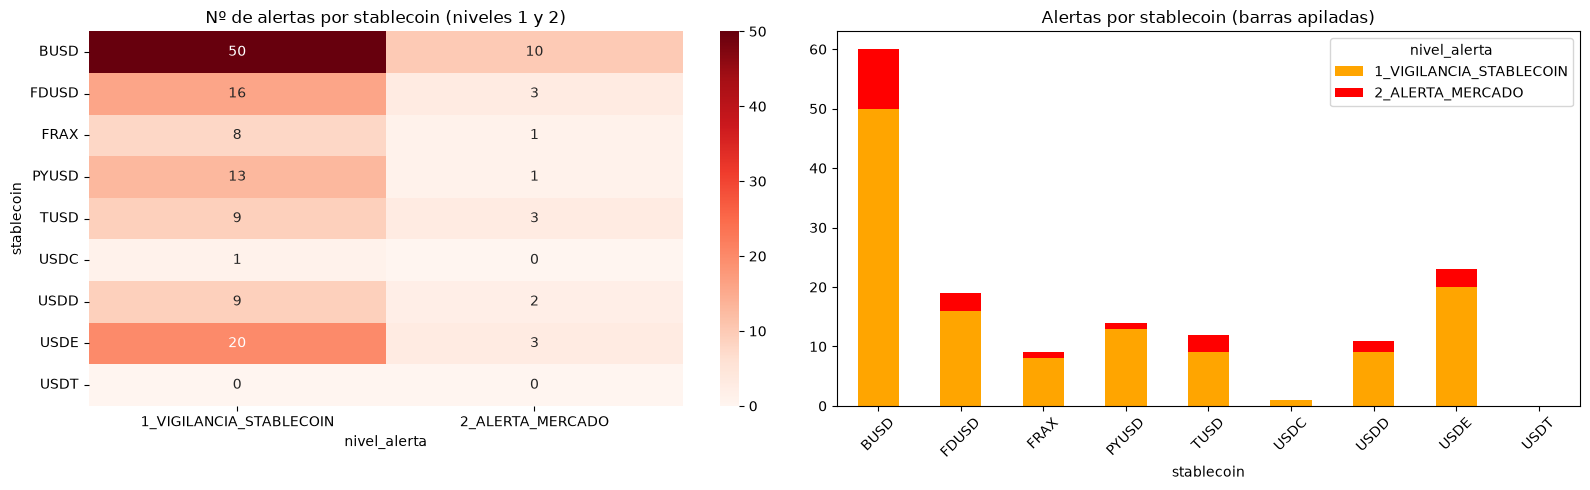

In [32]:
ct = pd.crosstab(df_alertas["stablecoin"], df_alertas["nivel_alerta"])
ct_alertas = ct[["1_VIGILANCIA_STABLECOIN", "2_ALERTA_MERCADO"]]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.heatmap(ct_alertas, annot=True, fmt="d", cmap="Reds", ax=axes[0])
axes[0].set_title("Nº de alertas por stablecoin (niveles 1 y 2)")

ct_alertas.plot(kind="bar", stacked=True, ax=axes[1], color=["orange", "red"])
axes[1].set_title("Alertas por stablecoin (barras apiladas)")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

#### Análisis del Comportamiento por Activos

Puedes estructurar la explicación yendo desde la stablecoin más problemática hasta la más segura:

- BUSD (El principal foco de riesgo): 

El activo más inestable del ecosistema analizado. Registra un total de 58 alertas acumuladas (48 de Vigilancia individual y 10 de Alerta de Mercado).

- TUSD y FRAX (Riesgo moderado/intermedio):

 TUSD acumula 12 alertas en total (9 de Vigilancia y 3 de Alerta de Mercado), posicionándose como el segundo activo con más incidencias.

 FRAX se mantiene cerca con 8 alertas en total (7 de Vigilancia y 1 de Alerta de Mercado). Ambas demuestran una tendencia a sufrir pérdidas de paridad ocasionales que requieren atención, aunque a una escala mucho menor que BUSD.

- USDC y USDT (Los gigantes seguros):

 USDC muestra un comportamiento excelente, registrando únicamente 1 alerta aislada de Vigilancia y ninguna de mercado.

 USDT (El ancla del mercado): Presenta un histórico impecable con 0 alertas de ningún tipo. Esto es crucial: a pesar de que en los gráficos anteriores vimos que USDT acumulaba muchos valores atípicos (outliers) debido a su inmenso volumen transaccional, este gráfico demuestra que esos movimientos nunca llegaron a romper los umbrales críticos del sistema para activar una alerta real

Clasifica claramente a BUSD como el activo de mayor riesgo sistémico e individual, mientras que consolida a USDT y USDC como las opciones más robustas y estables, demostrando una resistencia casi total a los momentos de estrés del mercado.

## 7. Notas

- `alertas_criticas_informe.csv` ya trae, para cada evento de nivel 2, una `narrativa_alerta` en texto
  generada automáticamente — útil para un informe ejecutivo, pero no se usa directamente en el análisis
  numérico de este notebook (son 20 filas, ya cubiertas por el cruce de arriba con más contexto).
- Si quieres profundizar en un evento concreto, filtra `df_criticas` por fecha o por stablecoin y cruza
  con `df_stable`/`df_crypto` en una ventana de +/- unos días alrededor del evento.